# Change-point по правдоподобию фильтра Калмана

Проверка одной гипотезы. Фильтр подгоняется по точкам `move`. На штатном ходе невязка остаётся небольшой, а логарифм правдоподобия держится в узкой полосе. Первая точка `anomaly`, которая не продолжает это движение, должна увести правдоподобие вниз. В такой точке ставится `change_point`, и фильтр открывает новую локальную систему координат: начало отсчёта переносится в эту точку, состояние обнуляется. Точки между соседними `change_point` образуют один отрезок.

Ожидание: эти отрезки близки к нарезке ряда на непрерывные куски `move` и `anomaly`, и в первую очередь не смешивают один класс с другим.

Срез данных, очистка и размеры выборок: индексы `[200000, 350000)`, только `move` и `anomaly`, последние 50 000 точек — тест. Шум фильтра и порог правдоподобия выбираются по `move` обучения. Карта и метрики гипотезы считаются по тесту.

Две модели — `app/old/working/kalman_filter_cv.py` и `kalman_filter_rw.py`.

- Постоянная скорость. Состояние $$ (e, n, v_e, v_n) $$ белый шум ускорения $$ \sigma_a $$  шум измерения $$ \sigma_{\mathrm{meas}} $$
- Случайное блуждание. Состояние $$ (e, n) $$ $$ Q = \sigma_{rw}^2 \Delta t \, I $$

Правдоподобие шага — плотность прогноза измерения:

$$ \log p(z_k \mid z_{1:k-1}) = -\frac12 \bigl(2\log 2\pi + \log\det S_k + \nu_k^\top S_k^{-1}\nu_k\bigr) $$

Порог — квантиль 0,5% этого логарифма на шагах `move` обучения. На ходу такой `change_point` приходится примерно на один шаг из двухсот. Всё, что для подогнанной модели ещё менее правдоподобно, открывает новую систему.

In [20]:
import sys
import types
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import LineCollection
from scipy.stats import chi2
from shapely.geometry import LineString
from sklearn.metrics import adjusted_rand_score, homogeneity_completeness_v_measure

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

START_IND = 200_000
END_IND = 350_000
TEST_SIZE = 50_000
# Пауза, после которой прогноз постоянной скорости уже не имеет смысла.
GAP_SECONDS = 180.0
# Квантиль логарифма правдоподобия на move. Ниже него — change_point.
TAIL_PERCENT = 0.5
EARTH_RADIUS_M = 6_371_000.0
CHI2_MEDIAN = float(chi2.median(2))


def find_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "2.csv").exists() and (candidate / "app").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с data/2.csv")


path_root = find_root()
path = path_root / "data" / "2.csv"
print(f"Корень: {path_root}")
print(f"Файл: {path}")
print(f"Медиана χ²(2) = {CHI2_MEDIAN:.3f}")

Корень: C:\Users\svaga\PycharmProjects\statistical_researchs
Файл: C:\Users\svaga\PycharmProjects\statistical_researchs\data\2.csv
Медиана χ²(2) = 1.386


# Данные

Из `data/2.csv` берётся фрагмент `raw.iloc[START_IND:END_IND]`. Удаляются `sat` и `is_water`, пустые координаты и нулевые широта или долгота. `stand` и любые другие метки отбрасываются. Оставшиеся `move` и `anomaly` сортируются по времени. Последние `TEST_SIZE` точек — тест, всё предыдущее — обучение. Параметры фильтра считаются только по непрерывным кускам `move` внутри обучения.

In [21]:
raw_full = pd.read_csv(path)
raw = raw_full.iloc[START_IND:END_IND].reset_index(drop=True)

frame = raw.drop(columns=["sat", "is_water"]).copy()
frame["lat"] = pd.to_numeric(frame["lat"], errors="coerce")
frame["lon"] = pd.to_numeric(frame["lon"], errors="coerce")
keep = frame["lat"].notna() & frame["lon"].notna() & (frame["lat"] != 0.0) & (frame["lon"] != 0.0)
frame = frame.loc[keep].reset_index(drop=True)
status = frame["status"].astype(str)
n_stand = int((status == "stand").sum())
n_other = int((~status.isin(["move", "anomaly", "stand"])).sum())
frame = frame.loc[status.isin(["move", "anomaly"])].reset_index(drop=True)
order = np.argsort(pd.to_datetime(frame["time"]).to_numpy(), kind="mergesort")
frame = frame.iloc[order].reset_index(drop=True)

if len(frame) <= TEST_SIZE:
    raise RuntimeError(
        f"После очистки осталось {len(frame)} строк, этого мало для теста из {TEST_SIZE}."
    )

stamp = pd.to_datetime(frame["time"])
t_sec = stamp.to_numpy().astype("datetime64[ns]").astype(np.int64) / 1e9
lat = frame["lat"].to_numpy(dtype=float)
lon = frame["lon"].to_numpy(dtype=float)
anom = frame["status"].astype(str).to_numpy() == "anomaly"
if np.any(np.diff(t_sec) <= 0.0):
    raise RuntimeError("Время после сортировки не строго возрастает.")

train_end = len(frame) - TEST_SIZE


def nfmt(value):
    return f"{int(value):,}".replace(",", " ")


print(
    f"Файл целиком: {nfmt(len(raw_full))} строк, "
    f"фрагмент [{START_IND}:{END_IND}): {nfmt(len(raw))} строк"
)
print(
    f"Отброшено stand: {nfmt(n_stand)}. "
    f"Отброшено других меток: {nfmt(n_other)}. "
    f"Осталось move и anomaly: {nfmt(len(frame))}."
)
print(
    f"Обучение {nfmt(train_end)} точек, anomaly {anom[:train_end].mean():.1%}. "
    f"Тест {nfmt(TEST_SIZE)} точек, anomaly {anom[train_end:].mean():.1%}."
)

Файл целиком: 419 453 строк, фрагмент [200000:350000): 150 000 строк
Отброшено stand: 6 842. Отброшено других меток: 0. Осталось move и anomaly: 143 158.
Обучение 93 158 точек, anomaly 45.1%. Тест 50 000 точек, anomaly 77.2%.


# Фильтры и новая система координат

Оба фильтра повторяют формулы из `kalman_filter_cv.py` и `kalman_filter_rw.py`: матрицы \(F\) и \(Q\), обновление J, логарифм правдоподобия и квадрат расстояния Махаланобиса. У постоянной скорости первый шаг новой системы задаёт скорость и порогом не проверяется — так же, как `KalmanFilterCV` инициализирует скорость по первой паре точек. У случайного блуждания проверяется каждый шаг: прогноз этого шага — остаться на месте.

Координаты внутри фильтра — локальные восток и север в метрах. На `change_point` и на паузе длиннее 180 с начало отсчёта переносится в текущую точку, а состояние собирается заново. Пауза — тоже новая система, но это не `change_point`: через много минут постоянная скорость уже ничего не прогнозирует. `change_point` ставится только когда логарифм правдоподобия ниже порога.



In [22]:
_LOG2PI = np.log(2.0 * np.pi)
_H_CV = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]], dtype=np.float64)
_I4 = np.eye(4, dtype=np.float64)
_I2 = np.eye(2, dtype=np.float64)


def _cv_transition(dt):
    F = np.eye(4, dtype=np.float64)
    F[0, 2] = dt
    F[1, 3] = dt
    return F


def _cv_process_noise(dt, sigma_acc):
    sa2 = float(sigma_acc) ** 2
    dt2 = dt * dt
    dt3 = dt2 * dt
    dt4 = dt2 * dt2
    Q = np.zeros((4, 4), dtype=np.float64)
    Q[0, 0] = Q[1, 1] = 0.25 * dt4 * sa2
    Q[2, 2] = Q[3, 3] = dt2 * sa2
    Q[0, 2] = Q[2, 0] = Q[1, 3] = Q[3, 1] = 0.5 * dt3 * sa2
    return Q


def _likelihood_step(innov, S):
    """innov (2,1), S (2,2) -> ll, m2 или None при плохой S."""
    S = 0.5 * (S + S.T)
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0 or not np.isfinite(logdet):
        return None
    solved = np.linalg.solve(S, innov)
    m2 = max(float((innov.T @ solved).item()), 0.0)
    ll = -0.5 * (2.0 * _LOG2PI + logdet + m2)
    return ll, m2


def _joseph(P_pred, K, H, R):
    I_KH = np.eye(P_pred.shape[0]) - K @ H
    P = I_KH @ P_pred @ I_KH.T + K @ R @ K.T
    return 0.5 * (P + P.T)


def cv_filter(lat_s, lon_s, t_s, sigma_acc, sigma_meas, threshold, gap=GAP_SECONDS):
    # Пошаговый KalmanFilterCV: при провале правдоподобия шаг не входит в состояние.
    count = len(lat_s)
    loglik = np.full(count, np.nan)
    nis = np.full(count, np.nan)
    innov_m = np.full(count, np.nan)
    change = np.zeros(count, dtype=bool)
    gap_break = np.zeros(count, dtype=bool)
    init_step = np.zeros(count, dtype=bool)
    seg = np.zeros(count, dtype=np.int32)
    sm2 = float(sigma_meas) ** 2
    R = np.eye(2, dtype=np.float64) * sm2
    lat0 = float(lat_s[0])
    lon0 = float(lon_s[0])
    cos0 = np.cos(np.radians(lat0))
    X = np.zeros((4, 1), dtype=np.float64)
    P = np.diag([500.0, 500.0, 1.0, 1.0]).astype(np.float64)
    sid = 0
    pending = True

    def reset(index):
        nonlocal lat0, lon0, cos0, X, P, pending, sid
        lat0 = float(lat_s[index])
        lon0 = float(lon_s[index])
        cos0 = np.cos(np.radians(lat0))
        X[:] = 0.0
        P[:] = np.diag([500.0, 500.0, 1.0, 1.0])
        pending = True
        sid += 1
        seg[index] = sid

    for index in range(1, count):
        dt = float(t_s[index] - t_s[index - 1])
        if dt > gap or dt <= 0.0:
            gap_break[index] = True
            reset(index)
            continue
        east = np.radians(lon_s[index] - lon0) * cos0 * EARTH_RADIUS_M
        north = np.radians(lat_s[index] - lat0) * EARTH_RADIUS_M
        just_init = False
        if pending:
            X[:] = [[0.0], [0.0], [east / dt], [north / dt]]
            vel_var = 2.0 * sm2 / (dt * dt)
            P[:] = np.diag([500.0, 500.0, vel_var, vel_var])
            pending = False
            just_init = True
            init_step[index] = True
        F = _cv_transition(dt)
        Q = _cv_process_noise(dt, sigma_acc)
        X_pred = F @ X
        P_pred = F @ P @ F.T + Q
        z = np.array([[east], [north]], dtype=np.float64)
        innov = z - _H_CV @ X_pred
        S = _H_CV @ P_pred @ _H_CV.T + R
        scored = _likelihood_step(innov, S)
        if scored is None:
            gap_break[index] = True
            reset(index)
            continue
        ll, m2 = scored
        loglik[index] = ll
        nis[index] = m2
        innov_m[index] = float(np.linalg.norm(innov))
        if ll < threshold and not just_init:
            change[index] = True
            reset(index)
            continue
        K = np.linalg.solve(S, _H_CV @ P_pred).T
        X = X_pred + K @ innov
        P = _joseph(P_pred, K, _H_CV, R)
        seg[index] = sid
    return loglik, nis, innov_m, change, gap_break, seg, init_step


def rw_filter(lat_s, lon_s, t_s, sigma_rw, sigma_meas, threshold, gap=GAP_SECONDS):
    count = len(lat_s)
    loglik = np.full(count, np.nan)
    nis = np.full(count, np.nan)
    innov_m = np.full(count, np.nan)
    change = np.zeros(count, dtype=bool)
    gap_break = np.zeros(count, dtype=bool)
    init_step = np.zeros(count, dtype=bool)
    seg = np.zeros(count, dtype=np.int32)
    sr2 = float(sigma_rw) ** 2
    sm2 = float(sigma_meas) ** 2
    R = np.eye(2, dtype=np.float64) * sm2
    lat0 = float(lat_s[0])
    lon0 = float(lon_s[0])
    cos0 = np.cos(np.radians(lat0))
    X = np.zeros((2, 1), dtype=np.float64)
    P = np.eye(2, dtype=np.float64) * sm2
    sid = 0

    def reset(index):
        nonlocal lat0, lon0, cos0, X, P, sid
        lat0 = float(lat_s[index])
        lon0 = float(lon_s[index])
        cos0 = np.cos(np.radians(lat0))
        X[:] = 0.0
        P[:] = np.eye(2, dtype=np.float64) * sm2
        sid += 1
        seg[index] = sid

    for index in range(1, count):
        dt = float(t_s[index] - t_s[index - 1])
        if dt > gap or dt <= 0.0:
            gap_break[index] = True
            reset(index)
            continue
        east = np.radians(lon_s[index] - lon0) * cos0 * EARTH_RADIUS_M
        north = np.radians(lat_s[index] - lat0) * EARTH_RADIUS_M
        Q = np.eye(2, dtype=np.float64) * (sr2 * dt)
        X_pred = X
        P_pred = P + Q
        z = np.array([[east], [north]], dtype=np.float64)
        innov = z - X_pred
        S = P_pred + R
        scored = _likelihood_step(innov, S)
        if scored is None:
            gap_break[index] = True
            reset(index)
            continue
        ll, m2 = scored
        loglik[index] = ll
        nis[index] = m2
        innov_m[index] = float(np.linalg.norm(innov))
        if ll < threshold:
            change[index] = True
            reset(index)
            continue
        K = np.linalg.solve(S, P_pred).T
        X = X_pred + K @ innov
        P = _joseph(P_pred, K, _I2, R)
        seg[index] = sid
    return loglik, nis, innov_m, change, gap_break, seg, init_step


def load_reference_filters():
    package = types.ModuleType("app.working")
    package.__path__ = []
    dependency = types.ModuleType("app.working.data_processor")

    class DataProcessor:
        pass

    dependency.DataProcessor = DataProcessor
    sys.modules["app.working"] = package
    sys.modules["app.working.data_processor"] = dependency
    loaded = []
    for name in ("kalman_filter_cv.py", "kalman_filter_rw.py"):
        file_path = path_root / "app" / "old" / "working" / name
        spec = importlib.util.spec_from_file_location(name.replace(".py", ""), file_path)
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        loaded.append(module)
    return loaded[0].KalmanFilterCV, loaded[1].KalmanFilterRW


def project_m(lat_s, lon_s, lat0, lon0):
    east = np.radians(lon_s - lon0) * np.cos(np.radians(lat0)) * EARTH_RADIUS_M
    north = np.radians(lat_s - lat0) * EARTH_RADIUS_M
    return np.column_stack([east, north])


KalmanFilterCV, KalmanFilterRW = load_reference_filters()

# Непрерывный кусок move без пауз: на нём пакетный класс и пошаговый фильтр обязаны совпасть.
move_bounds = np.r_[0, np.flatnonzero(anom[1:] != anom[:-1]) + 1, len(anom)]
check_slice = None
for left, right in zip(move_bounds[:-1], move_bounds[1:]):
    if anom[left] or right > train_end or right - left < 400:
        continue
    dt = np.diff(t_sec[left:right])
    if np.all((dt > 0.0) & (dt <= GAP_SECONDS)):
        check_slice = (left, left + 400)
        break
if check_slice is None:
    raise RuntimeError("Не найден непрерывный кусок move для сверки с классом.")
left, right = check_slice
origin_lat = float(lat[left])
origin_lon = float(lon[left])
xy = project_m(lat[left:right], lon[left:right], origin_lat, origin_lon)
time64 = (t_sec[left:right] * 1e9).astype("datetime64[ns]")
sa_check, sm_check = 0.004, 0.8
ref_cv = KalmanFilterCV(sigma_acc=sa_check, sigma_meas=sm_check)
_, _, ll_ref, _ = ref_cv.filter(xy[:, 0], xy[:, 1], time64)
ll_own, *_ = cv_filter(lat[left:right], lon[left:right], t_sec[left:right], sa_check, sm_check, -1e300)
cv_gap = float(np.nanmax(np.abs(ll_ref - ll_own)))
ref_rw = KalmanFilterRW(sigma_rw=12.0, sigma_meas=4.0)
_, _, ll_ref_rw, _ = ref_rw.filter(xy[:, 0], xy[:, 1], time64)
ll_own_rw, *_ = rw_filter(lat[left:right], lon[left:right], t_sec[left:right], 12.0, 4.0, -1e300)
rw_gap = float(np.nanmax(np.abs(ll_ref_rw - ll_own_rw)))
print(f"Сверка на точках [{left}:{right}).")
print(f"Постоянная скорость: max |Δ log p| = {cv_gap:.3e}")
print(f"Случайное блуждание: max |Δ log p| = {rw_gap:.3e}")
if cv_gap > 1e-4 or rw_gap > 1e-4:
    raise RuntimeError("Пошаговый фильтр разошёлся с классом из app/old/working.")


Сверка на точках [22080:22480).
Постоянная скорость: max |Δ log p| = 0.000e+00
Случайное блуждание: max |Δ log p| = 0.000e+00


# Параметры по точкам move

Непрерывный кусок `move` — это точки одной метки без паузы длиннее 180 с. На нескольких самых длинных кусках обучения перебирается сетка шумов. Выбирается узел с наибольшей медианой логарифма правдоподобия: это оценка шума по типичному шагу хода, без подстройки под редкие сбои внутри метки `move`.

Рядом печатаются медиана модуля невязки и медиана NIS. У согласованного фильтра медиана NIS близка к медиане $$ \chi^2 $$ с двумя степенями свободы. Большая невязка на `move` означает, что модель этот ход не держит.

In [23]:
def move_pieces(limit):
    pieces = []
    bounds = np.r_[0, np.flatnonzero(anom[1:] != anom[:-1]) + 1, limit]
    for left, right in zip(bounds[:-1], bounds[1:]):
        if anom[left]:
            continue
        start = left
        for index in range(left + 1, right):
            dt = t_sec[index] - t_sec[index - 1]
            if dt > GAP_SECONDS or dt <= 0.0:
                if index - start >= 8:
                    pieces.append((start, index))
                start = index
        if right - start >= 8:
            pieces.append((start, right))
    pieces.sort(key=lambda pair: pair[1] - pair[0], reverse=True)
    return pieces


def pooled_move_stats(kind, pieces, params):
    log_parts = []
    innov_parts = []
    nis_parts = []
    for left, right in pieces:
        if kind == "cv":
            ll, nis, inn, *_ = cv_filter(
                lat[left:right], lon[left:right], t_sec[left:right], params[0], params[1], -1e300
            )
        else:
            ll, nis, inn, *_ = rw_filter(
                lat[left:right], lon[left:right], t_sec[left:right], params[0], params[1], -1e300
            )
        ok = np.isfinite(ll)
        if np.count_nonzero(ok) < 5:
            continue
        log_parts.append(ll[ok])
        innov_parts.append(inn[ok])
        nis_parts.append(nis[ok])
    log_all = np.concatenate(log_parts)
    innov_all = np.concatenate(innov_parts)
    nis_all = np.concatenate(nis_parts)
    return log_all, innov_all, nis_all


def search_noise(kind, grid_a, grid_b, spans):
    rows = []
    for first in grid_a:
        for second in grid_b:
            log_all, innov_all, nis_all = pooled_move_stats(kind, spans, (first, second))
            rows.append(
                {
                    "a": float(first),
                    "b": float(second),
                    "med_ll": float(np.median(log_all)),
                    "med_inn": float(np.median(innov_all)),
                    "p95_inn": float(np.percentile(innov_all, 95)),
                    "med_nis": float(np.median(nis_all)),
                }
            )
    table = pd.DataFrame(rows).sort_values(["med_ll", "med_inn"], ascending=[False, True])
    best = table.iloc[0]
    expanded = False
    extra_a = []
    extra_b = []
    if np.isclose(best["a"], np.min(grid_a)) or np.isclose(best["a"], np.max(grid_a)):
        factor = 0.5 if np.isclose(best["a"], np.min(grid_a)) else 2.0
        extra_a.append(float(best["a"]) * factor)
        expanded = True
    if np.isclose(best["b"], np.min(grid_b)) or np.isclose(best["b"], np.max(grid_b)):
        factor = 0.5 if np.isclose(best["b"], np.min(grid_b)) else 2.0
        extra_b.append(float(best["b"]) * factor)
        expanded = True
    if expanded:
        grid_a = np.unique(np.r_[grid_a, extra_a if extra_a else grid_a[:0]])
        grid_b = np.unique(np.r_[grid_b, extra_b if extra_b else grid_b[:0]])
        # Достаточно новой строки и нового столбца, а не всей сетки заново.
        fresh = []
        for first in extra_a or []:
            for second in grid_b:
                fresh.append((first, second))
        for second in extra_b or []:
            for first in grid_a:
                if any(np.isclose(first, item[0]) and np.isclose(second, item[1]) for item in fresh):
                    continue
                fresh.append((first, second))
        for first, second in fresh:
            log_all, innov_all, nis_all = pooled_move_stats(kind, spans, (first, second))
            rows.append(
                {
                    "a": float(first),
                    "b": float(second),
                    "med_ll": float(np.median(log_all)),
                    "med_inn": float(np.median(innov_all)),
                    "p95_inn": float(np.percentile(innov_all, 95)),
                    "med_nis": float(np.median(nis_all)),
                }
            )
        table = pd.DataFrame(rows).sort_values(["med_ll", "med_inn"], ascending=[False, True])
    return table.reset_index(drop=True)


pieces = move_pieces(train_end)
fit_spans = []
for left, right in pieces:
    fit_spans.append((left, min(right, left + 4_000)))
    if len(fit_spans) == 4:
        break
fit_points = sum(right - left for left, right in fit_spans)
print(
    f"Кусков move в обучении: {len(pieces)}. "
    f"В подгонку вошли {len(fit_spans)} самых длинных, {nfmt(fit_points)} точек."
)

cv_table = search_noise(
    "cv",
    np.array([0.001, 0.002, 0.004, 0.008, 0.02]),
    np.array([0.15, 0.3, 0.8, 2.0, 6.0]),
    fit_spans,
)
rw_table = search_noise(
    "rw",
    np.array([6.0, 10.0, 14.0, 20.0, 30.0]),
    np.array([1.0, 4.0, 12.0, 30.0]),
    fit_spans,
)
cv_best = cv_table.iloc[0]
rw_best = rw_table.iloc[0]
cv_params = (float(cv_best["a"]), float(cv_best["b"]))
rw_params = (float(rw_best["a"]), float(rw_best["b"]))

print("Постоянная скорость, лучшие узлы сетки (медиана log p на move):")
display(cv_table.head(8).rename(columns={"a": "sigma_acc", "b": "sigma_meas"}).round(3))
print(
    f"Выбрано σ_a = {cv_params[0]:.4g} м/с², σ_meas = {cv_params[1]:.4g} м. "
    f"Медиана невязки {cv_best['med_inn']:.2f} м, p95 {cv_best['p95_inn']:.1f} м, "
    f"медиана NIS {cv_best['med_nis']:.2f}."
)
print("Случайное блуждание, лучшие узлы:")
display(rw_table.head(8).rename(columns={"a": "sigma_rw", "b": "sigma_meas"}).round(3))
print(
    f"Выбрано σ_rw = {rw_params[0]:.4g} м/√с, σ_meas = {rw_params[1]:.4g} м. "
    f"Медиана невязки {rw_best['med_inn']:.2f} м, p95 {rw_best['p95_inn']:.1f} м, "
    f"медиана NIS {rw_best['med_nis']:.2f}."
)

Кусков move в обучении: 53. В подгонку вошли 4 самых длинных, 16 000 точек.
Постоянная скорость, лучшие узлы сетки (медиана log p на move):


,sigma_acc,sigma_meas,med_ll,med_inn,p95_inn,med_nis
0,0.004,0.150,-1.582,0.736,6.080,2.663
1,0.008,0.150,-1.601,0.714,6.630,1.147
2,0.004,0.300,-1.785,0.819,5.907,1.519
3,0.008,0.075,-1.925,0.876,9.812,2.632
4,0.004,0.075,-1.938,0.714,6.630,4.586
5,0.008,0.300,-1.963,0.736,6.080,0.666
6,0.002,0.300,-2.418,1.020,6.128,3.688
7,0.020,0.150,-2.615,0.958,10.513,0.557


Выбрано σ_a = 0.004 м/с², σ_meas = 0.15 м. Медиана невязки 0.74 м, p95 6.1 м, медиана NIS 2.66.
Случайное блуждание, лучшие узлы:


,sigma_rw,sigma_meas,med_ll,med_inn,p95_inn,med_nis
0,10.0,0.5,-9.825,46.468,53.727,2.158
1,10.0,1.0,-9.827,46.503,53.767,2.158
2,10.0,4.0,-9.856,47.187,54.560,2.158
3,14.0,0.5,-9.969,46.462,53.721,1.101
4,14.0,1.0,-9.970,46.480,53.741,1.101
5,14.0,4.0,-9.985,46.834,54.148,1.101
6,10.0,12.0,-10.065,52.381,60.529,2.157
7,14.0,12.0,-10.102,49.645,57.384,1.101


Выбрано σ_rw = 10 м/√с, σ_meas = 0.5 м. Медиана невязки 46.47 м, p95 53.7 м, медиана NIS 2.16.


# Порог и нарезка ряда

Порог считается по всем кускам `move` обучения, уже с выбранным шумом. Это квантиль 0,5% логарифма правдоподобия. Метки `anomaly` в выборе порога не участвуют.

Дальше один и тот же порог применяется к тесту, где `move` и `anomaly` идут вперемешку по времени. Фильтр идёт по ряду. Если логарифм правдоподобия падает ниже порога, точка становится `change_point` и началом новой системы. Пауза длиннее 180 с тоже открывает новую систему, отдельным флагом.

Для сравнения с метками тест режется на непрерывные пробеги одного класса. Совпадение двух нарезок измеряется так:

- чистота отрезка — доля его большинства, взвешенная длиной;
- однородность, полнота, V-мера и ARI — между номером отрезка фильтра и номером пробега метки;
- граница классов поймана, если `change_point` или пауза стоят на её индексе либо на соседнем шаге;
- точность `change_point` — доля таких точек, которые попали в эту окрестность границы классов.

Итог выводится двумя таблицами: узкая сводка по отрезкам и границам классов, и таблица квантилей длин отрезков фильтра (move и anomaly; точки и км). Пробеги по меткам в таблицу не входят.

Отдельно, уже без смены системы на каждом падении, на тесте смотрится сырое правдоподобие: внутренние шаги `move`, первый шаг перехода `move → anomaly` и остальные точки `anomaly`. Так видно, проваливается ли правдоподобие именно на входе в `anomaly`.

In [24]:
def run_model(kind, left, right, threshold):
    if kind == "cv":
        return cv_filter(
            lat[left:right], lon[left:right], t_sec[left:right], cv_params[0], cv_params[1], threshold
        )
    return rw_filter(
        lat[left:right], lon[left:right], t_sec[left:right], rw_params[0], rw_params[1], threshold
    )


def class_run_id(mask):
    return np.cumsum(np.r_[0, mask[1:] != mask[:-1]]).astype(np.int32)


def class_bounds(mask):
    return np.flatnonzero(mask[1:] != mask[:-1]) + 1




def haversine_path_m(lat_s, lon_s, chosen):
    """Длина ломаной по выбранным подряд идущим индексам, метры."""
    idx = np.flatnonzero(chosen)
    if len(idx) < 2:
        return 0.0
    lat = np.asarray(lat_s, dtype=float)[idx]
    lon = np.asarray(lon_s, dtype=float)[idx]
    latr = np.radians(lat)
    lonr = np.radians(lon)
    dlat = np.diff(latr)
    dlon = np.diff(lonr)
    step = np.sin(dlat / 2.0) ** 2 + np.cos(latr[:-1]) * np.cos(latr[1:]) * np.sin(dlon / 2.0) ** 2
    return float(2.0 * EARTH_RADIUS_M * np.arcsin(np.sqrt(np.clip(step, 0.0, 1.0))).sum())


def near_bounds(bounds, count, tol):
    mask = np.zeros(count, dtype=bool)
    for shift in range(-tol, tol + 1):
        idx = bounds + shift
        idx = idx[(idx >= 0) & (idx < count)]
        mask[idx] = True
    return mask


def lengths_by_majority(seg, mask, lat_s, lon_s):
    move_pts, anom_pts = [], []
    move_m, anom_m = [], []
    for sid in np.unique(seg):
        chosen = seg == sid
        n_pts = int(chosen.sum())
        path_m = haversine_path_m(lat_s, lon_s, chosen)
        if np.mean(mask[chosen]) >= 0.5:
            anom_pts.append(n_pts)
            anom_m.append(path_m)
        else:
            move_pts.append(n_pts)
            move_m.append(path_m)
    return (
        np.asarray(move_pts, dtype=float),
        np.asarray(anom_pts, dtype=float),
        np.asarray(move_m, dtype=float),
        np.asarray(anom_m, dtype=float),
    )


def true_lengths(mask, lat_s, lon_s):
    run_id = class_run_id(mask)
    move_pts, anom_pts = [], []
    move_m, anom_m = [], []
    for sid in np.unique(run_id):
        chosen = run_id == sid
        n_pts = int(chosen.sum())
        path_m = haversine_path_m(lat_s, lon_s, chosen)
        if mask[chosen][0]:
            anom_pts.append(n_pts)
            anom_m.append(path_m)
        else:
            move_pts.append(n_pts)
            move_m.append(path_m)
    return (
        np.asarray(move_pts, dtype=float),
        np.asarray(anom_pts, dtype=float),
        np.asarray(move_m, dtype=float),
        np.asarray(anom_m, dtype=float),
    )


def median_or_nan(values):
    if len(values) == 0:
        return float("nan")
    return float(np.median(values))



def length_stats(values):
    if len(values) == 0:
        nan = float("nan")
        return {"min": nan, "med": nan, "p75": nan, "p95": nan, "max": nan}
    arr = np.asarray(values, dtype=float)
    return {
        "min": float(np.min(arr)),
        "med": float(np.median(arr)),
        "p75": float(np.percentile(arr, 75)),
        "p95": float(np.percentile(arr, 95)),
        "max": float(np.max(arr)),
    }


def partition_metrics(mask, loglik, change, gap_break, seg, lat_s, lon_s):
    count = len(mask)
    bounds = class_bounds(mask)
    cut = change | gap_break
    hit_ll = 0
    hit_gap = 0
    hit_any = 0
    for bound in bounds:
        window = slice(max(0, bound - 1), min(count, bound + 2))
        ll_here = bool(np.any(change[window]))
        gap_here = bool(np.any(gap_break[window]))
        hit_ll += int(ll_here)
        hit_gap += int(gap_here and not ll_here)
        hit_any += int(ll_here or gap_here)
    near = near_bounds(bounds, count, tol=1) if len(bounds) else np.zeros(count, dtype=bool)
    n_change = int(change.sum())
    precision = float(np.mean(near[change])) if n_change else float("nan")
    run_id = class_run_id(mask)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(run_id, seg)
    mixed = 0
    majority = 0
    total = 0
    for sid in np.unique(seg):
        chosen = seg == sid
        total += int(chosen.sum())
        n_anom = int(np.count_nonzero(mask[chosen]))
        n_move = int(chosen.sum()) - n_anom
        majority += max(n_anom, n_move)
        mixed += int(n_anom > 0 and n_move > 0)
    move_pts, anom_pts, move_m, anom_m = lengths_by_majority(seg, mask, lat_s, lon_s)
    true_move_pts, true_anom_pts, true_move_m, true_anom_m = true_lengths(mask, lat_s, lon_s)
    move_points = int(np.count_nonzero(~mask))
    long_move_points = 0
    longest_move = 0
    for sid in np.unique(seg):
        chosen = seg == sid
        if np.mean(mask[chosen]) >= 0.5:
            continue
        longest_move = max(longest_move, int(chosen.sum()))
        if int(chosen.sum()) >= 200:
            long_move_points += int(np.count_nonzero(~mask[chosen]))
    return {
        "n_seg": int(seg.max()) + 1,
        "n_change": n_change,
        "n_change_move": int(np.count_nonzero(change & ~mask)),
        "n_change_anom": int(np.count_nonzero(change & mask)),
        "n_gap": int(gap_break.sum()),
        "n_bounds": int(len(bounds)),
        "hit_ll": int(hit_ll),
        "hit_gap": int(hit_gap),
        "hit_any": int(hit_any),
        "missed": int(len(bounds) - hit_any),
        "precision": precision,
        "purity": majority / total if total else float("nan"),
        "mixed": int(mixed),
        "homogeneity": float(homogeneity),
        "completeness": float(completeness),
        "v_measure": float(v_measure),
        "ari": float(adjusted_rand_score(run_id, seg)),
        "seg_move_pts": length_stats(move_pts),
        "seg_move_km": length_stats(move_m / 1000.0),
        "seg_anom_pts": length_stats(anom_pts),
        "seg_anom_km": length_stats(anom_m / 1000.0),
        "true_move_pts": length_stats(true_move_pts),
        "true_move_km": length_stats(true_move_m / 1000.0),
        "true_anom_pts": length_stats(true_anom_pts),
        "true_anom_km": length_stats(true_anom_m / 1000.0),
        "med_len_move": length_stats(move_pts)["med"],
        "med_len_anom": length_stats(anom_pts)["med"],
        "true_med_move": length_stats(true_move_pts)["med"],
        "true_med_anom": length_stats(true_anom_pts)["med"],
        "longest_move": int(longest_move),
        "move_in_long": (long_move_points / move_points) if move_points else float("nan"),
    }


def scout_groups(mask, loglik):
    bounds = class_bounds(mask)
    onset_anom = np.zeros(len(mask), dtype=bool)
    onset_move = np.zeros(len(mask), dtype=bool)
    if len(bounds):
        onset_anom[bounds[mask[bounds]]] = True
        onset_move[bounds[~mask[bounds]]] = True
    groups = {
        "move": loglik[(~mask) & np.isfinite(loglik)],
        "to_anomaly": loglik[onset_anom & np.isfinite(loglik)],
        "anomaly": loglik[mask & ~onset_anom & np.isfinite(loglik)],
        "to_move": loglik[onset_move & np.isfinite(loglik)],
    }
    return groups


move_log_cv, move_innov_cv, move_nis_cv = pooled_move_stats("cv", pieces, cv_params)
move_log_rw, move_innov_rw, move_nis_rw = pooled_move_stats("rw", pieces, rw_params)
tau_cv = float(np.percentile(move_log_cv, TAIL_PERCENT))
tau_rw = float(np.percentile(move_log_rw, TAIL_PERCENT))
print(
    f"Постоянная скорость. По всем кускам move обучения: "
    f"медиана невязки {np.median(move_innov_cv):.2f} м, "
    f"p95 {np.percentile(move_innov_cv, 95):.1f} м, "
    f"медиана NIS {np.median(move_nis_cv):.2f}, "
    f"медиана log p {np.median(move_log_cv):.2f}. "
    f"Порог {tau_cv:.2f}."
)
print(
    f"Случайное блуждание. Медиана невязки {np.median(move_innov_rw):.2f} м, "
    f"p95 {np.percentile(move_innov_rw, 95):.1f} м, "
    f"медиана NIS {np.median(move_nis_rw):.2f}, "
    f"медиана log p {np.median(move_log_rw):.2f}. "
    f"Порог {tau_rw:.2f}."
)

runs = {}
metrics = {}
for kind, tau in (("cv", tau_cv), ("rw", tau_rw)):
    for split, left, right in (("train", 0, train_end), ("test", train_end, len(frame))):
        scout = run_model(kind, left, right, -1e300)
        cut = run_model(kind, left, right, tau)
        runs[(kind, split, "scout")] = scout
        runs[(kind, split, "cut")] = cut
        metrics[(kind, split)] = partition_metrics(
            anom[left:right],
            cut[0],
            cut[3],
            cut[4],
            cut[5],
            lat[left:right],
            lon[left:right],
        )



_LENGTH_GROUPS = (
    ("отрезок move", "seg_move_pts", "seg_move_km"),
    ("отрезок anomaly", "seg_anom_pts", "seg_anom_km"),
)
_STAT_COLS = [("min", "min"), ("мед", "med"), ("p75", "p75"), ("p95", "p95"), ("max", "max")]


def _length_stats_row(model, sample, group, unit, stats):
    row = {"модель": model, "выборка": sample, "группа": group, "ед.": unit}
    for label, key in _STAT_COLS:
        row[label] = stats[key]
    return row


summary_rows = []
length_rows = []
for kind, title in (("cv", "постоянная скорость"), ("rw", "случайное блуждание")):
    for split, split_title in (("train", "обучение"), ("test", "тест")):
        item = metrics[(kind, split)]
        summary_rows.append(
            {
                "модель": title,
                "выборка": split_title,
                "отрезков": item["n_seg"],
                "change_point": item["n_change"],
                "из них anomaly": item["n_change_anom"],
                "из них move": item["n_change_move"],
                "пауз > 180 с": item["n_gap"],
                "границ классов": item["n_bounds"],
                "поймано правдоподобием": item["hit_ll"],
                "поймано только паузой": item["hit_gap"],
                "пропущено": item["missed"],
                "чистота": item["purity"],
                "однородность": item["homogeneity"],
                "V": item["v_measure"],
                "ARI": item["ari"],
            }
        )
        for group, pts_key, km_key in _LENGTH_GROUPS:
            length_rows.append(_length_stats_row(title, split_title, group, "точки", item[pts_key]))
            length_rows.append(_length_stats_row(title, split_title, group, "км", item[km_key]))

metrics_summary = pd.DataFrame(summary_rows).set_index(["модель", "выборка"])
metrics_lengths = pd.DataFrame(length_rows).set_index(["модель", "выборка", "группа", "ед."])

print("Сводка нарезки и согласованности с метками")
display(metrics_summary.round(3))
print("Распределения длин отрезков фильтра: min, медиана, p75, p95, max (точки и км)")
with pd.option_context("display.max_rows", 200, "display.max_columns", 20, "display.width", 120):
    display(metrics_lengths.round(3))


def rate_below(values, tau):
    if len(values) == 0:
        return float("nan")
    return float(np.mean(values < tau))


scout_summary = {}
for kind, tau in (("cv", tau_cv), ("rw", tau_rw)):
    groups = scout_groups(anom[train_end:], runs[(kind, "test", "scout")][0])
    scout_summary[kind] = {
        "move_med": float(np.median(groups["move"])) if len(groups["move"]) else float("nan"),
        "onset_med": float(np.median(groups["to_anomaly"])) if len(groups["to_anomaly"]) else float("nan"),
        "anom_med": float(np.median(groups["anomaly"])) if len(groups["anomaly"]) else float("nan"),
        "move_rate": rate_below(groups["move"], tau),
        "onset_rate": rate_below(groups["to_anomaly"], tau),
        "anom_rate": rate_below(groups["anomaly"], tau),
        "n_onset": int(len(groups["to_anomaly"])),
    }
    item = scout_summary[kind]
    title = "Постоянная скорость" if kind == "cv" else "Случайное блуждание"
    print(
        f"{title}, тест, фильтр без смены системы на падении. "
        f"Медиана log p: move {item['move_med']:.2f}, "
        f"первый шаг move→anomaly {item['onset_med']:.2f} (таких шагов {item['n_onset']}), "
        f"прочие anomaly {item['anom_med']:.2f}."
    )
    print(
        f"  Доля ниже порога {tau:.2f}: "
        f"move {item['move_rate']:.2%}, "
        f"первый шаг anomaly {item['onset_rate']:.2%}, "
        f"прочие anomaly {item['anom_rate']:.2%}."
    )

Постоянная скорость. По всем кускам move обучения: медиана невязки 0.90 м, p95 7.8 м, медиана NIS 4.03, медиана log p -2.27. Порог -2903.75.
Случайное блуждание. Медиана невязки 44.51 м, p95 57.2 м, медиана NIS 1.98, медиана log p -9.74. Порог -10.88.
Сводка нарезки и согласованности с метками


отрезков  change_point  из них anomaly  \
модель              выборка                                            
постоянная скорость обучение     12890         12458           12266   
                    тест          8371          8087            8050   
случайное блуждание обучение     25876         25444           25199   
                    тест         13236         12952           12877   

                              из них move  пауз > 180 с  границ классов  \
модель              выборка                                               
постоянная скорость обучение          192           431              48   
                    тест               37           283              12   
случайное блуждание обучение          245           431              48   
                    тест               75           283              12   

                              поймано правдоподобием  поймано только паузой  \
модель              выборка                                                   
постоянная скорость обучение                      23                     17   
                    тест                           9                      3   
случайное блуждание обучение                      30                     10   
                    тест                           9                      3   

                              пропущено  чистота  однородность      V    ARI  
модель              выборка                                                   
постоянная скорость обучение          8    0.994         0.991  0.603  0.140  
                    тест              0    1.000         1.000  0.275  0.015  
случайное блуждание обучение          8    0.994         0.991  0.581  0.103  
                    тест              0    1.000         1.000  0.276  0.011

Распределения длин отрезков фильтра: min, медиана, p75, p95, max (точки и км)


min     мед      p75       p95        max
модель              выборка  группа          ед.                                               
постоянная скорость обучение отрезок move    точки  1.000  45.500  234.250   889.750   3187.000
                                             км     0.000   1.110    8.743    33.451    150.803
                             отрезок anomaly точки  1.000   2.000    2.000     6.000   1476.000
                                             км     0.000   1.096    1.099     1.446  11861.656
                    тест     отрезок move    точки  2.000   7.000  188.500  1880.100   2106.000
                                             км     0.023   0.191    8.088    77.002    113.821
                             отрезок anomaly точки  1.000   2.000    3.000    12.000    455.000
                                             км     0.000   0.259    0.286     0.938   3370.370
случайное блуждание обучение отрезок move    точки  1.000  47.000  198.000   814.200   3000.000
                                             км     0.000   1.890    8.691    29.260     72.487
                             отрезок anomaly точки  1.000   1.000    1.000     1.000   1477.000
                                             км     0.000   0.000    0.000     0.000      9.659
                    тест     отрезок move    точки  1.000  15.000  118.500   804.100   1846.000
                                             км     0.000   0.823    6.747    35.977     76.537
                             отрезок anomaly точки  1.000   1.000    1.000     9.000    792.000
                                             км     0.000   0.000    0.000     0.283      4.633

Постоянная скорость, тест, фильтр без смены системы на падении. Медиана log p: move -2.20, первый шаг move→anomaly -362955.69 (таких шагов 5), прочие anomaly -1013.58.
  Доля ниже порога -2903.75: move 0.52%, первый шаг anomaly 100.00%, прочие anomaly 41.81%.
Случайное блуждание, тест, фильтр без смены системы на падении. Медиана log p: move -9.82, первый шаг move→anomaly -5347.94 (таких шагов 5), прочие anomaly -9.44.
  Доля ниже порога -10.88: move 0.65%, первый шаг anomaly 80.00%, прочие anomaly 33.58%.


# Отрезки на карте

Точки одной системы координат — один цвет и один `LineString` в координатах `(долгота, широта)`. Линия рвётся на `change_point`, на паузе длиннее 180 с и на смене системы: хорда через такую паузу не рисуется. Рядом тот же участок, разрезанный по меткам: каждый непрерывный пробег `move` или `anomaly` — свой цвет.

Подложка — тайлы OpenStreetMap (нужен интернет). Масштаб окна: если во фрагменте есть исходные точки `move`, границы — bbox этих точек плюс 5% поля с каждой стороны; иначе — bbox 95% точек (2,5–97,5 перцентили) плюс 5% поля. Сначала выводятся фрагменты train по 50 000 точек, затем test по 50 000. В каждом фрагменте слева пробеги меток, справа нарезка фильтра (сверху постоянная скорость, снизу случайное блуждание). Чёрная точка — `change_point`. Смена цвета без чёрной точки — пауза длиннее 180 с: фильтр открывает новую систему, но это не падение правдоподобия.


Постоянная скорость: 8371 систем координат, 8256 LineString, одиночных точек без ребра 115.
Случайное блуждание: 13236 систем координат, 2193 LineString, одиночных точек без ребра 11043.


,модель,segment_id,n_points,majority,purity,n_linestrings
0,постоянная скорость,0,60,anomaly,1.0,1
1,постоянная скорость,1,3,anomaly,1.0,1
2,постоянная скорость,2,2,anomaly,1.0,1
3,постоянная скорость,3,2,anomaly,1.0,1
4,постоянная скорость,4,2,anomaly,1.0,1
5,постоянная скорость,5,15,anomaly,1.0,1
6,случайное блуждание,0,64,anomaly,1.0,1
7,случайное блуждание,1,56,anomaly,1.0,1
8,случайное блуждание,2,6,anomaly,1.0,1
9,случайное блуждание,3,35,anomaly,1.0,1



=== Демонстрация треков train ===
Точек в выборке: 93 158, фрагментов по 25 000: 4.
Демонстрация треков train, фрагмент 1/4: глобальные индексы [0, 25000), точек 25000.


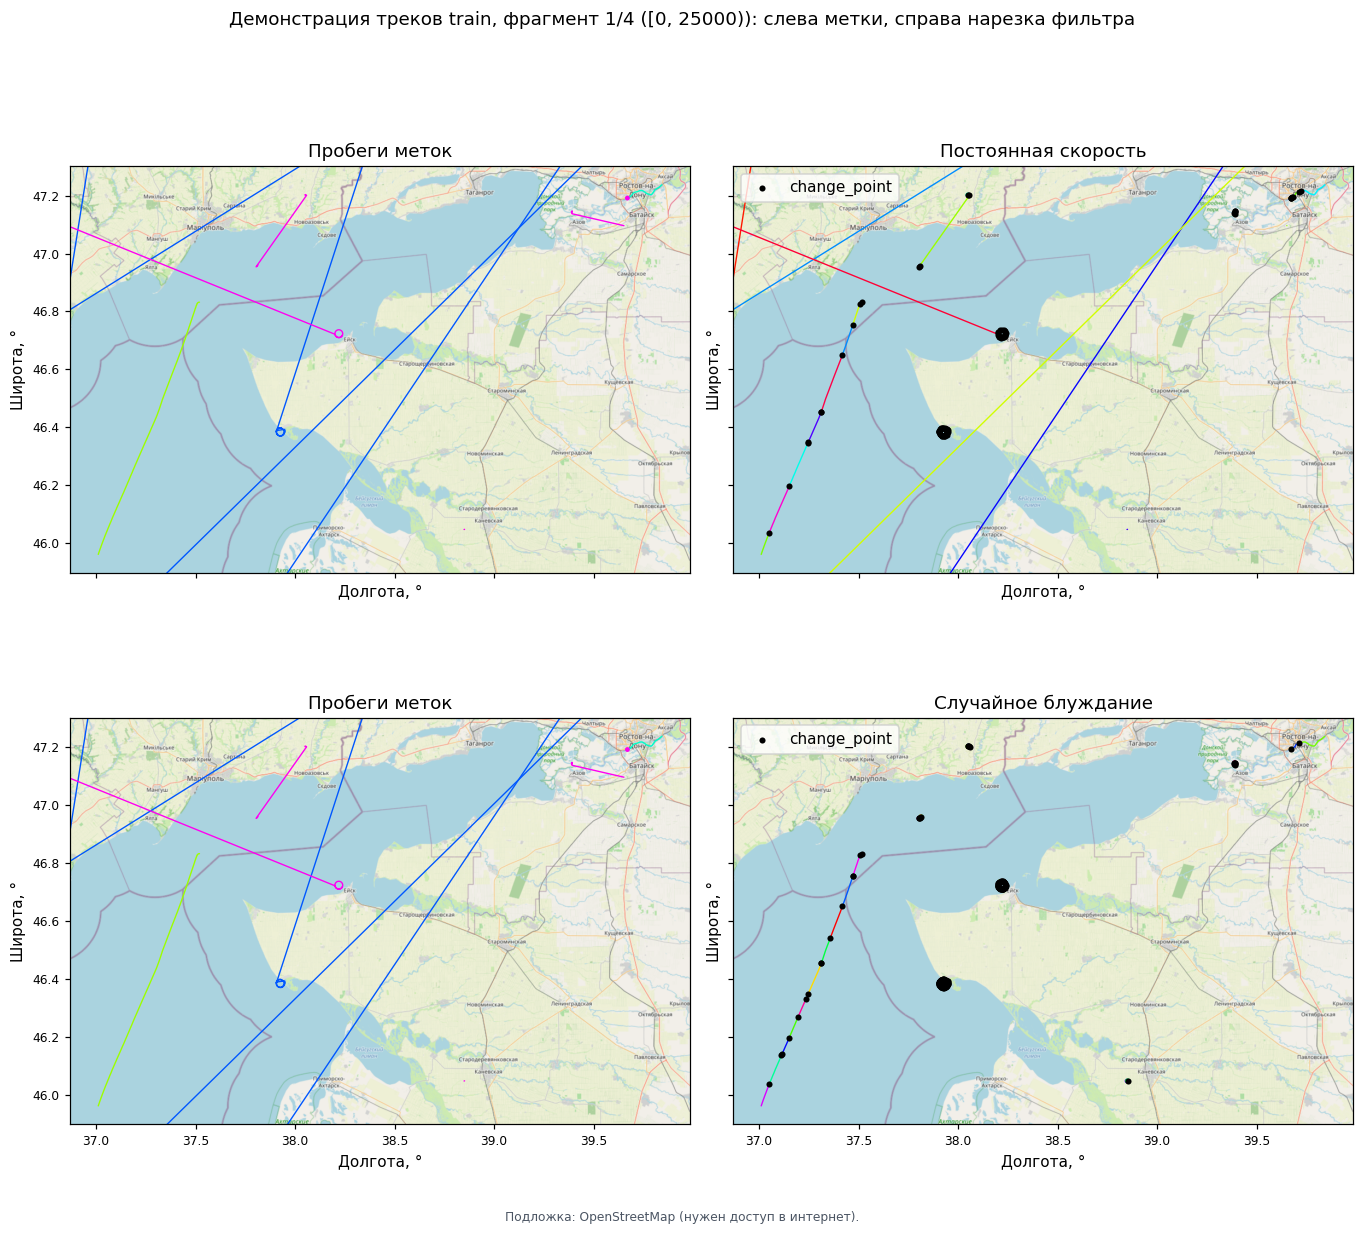

Демонстрация треков train, фрагмент 2/4: глобальные индексы [25000, 50000), точек 25000.


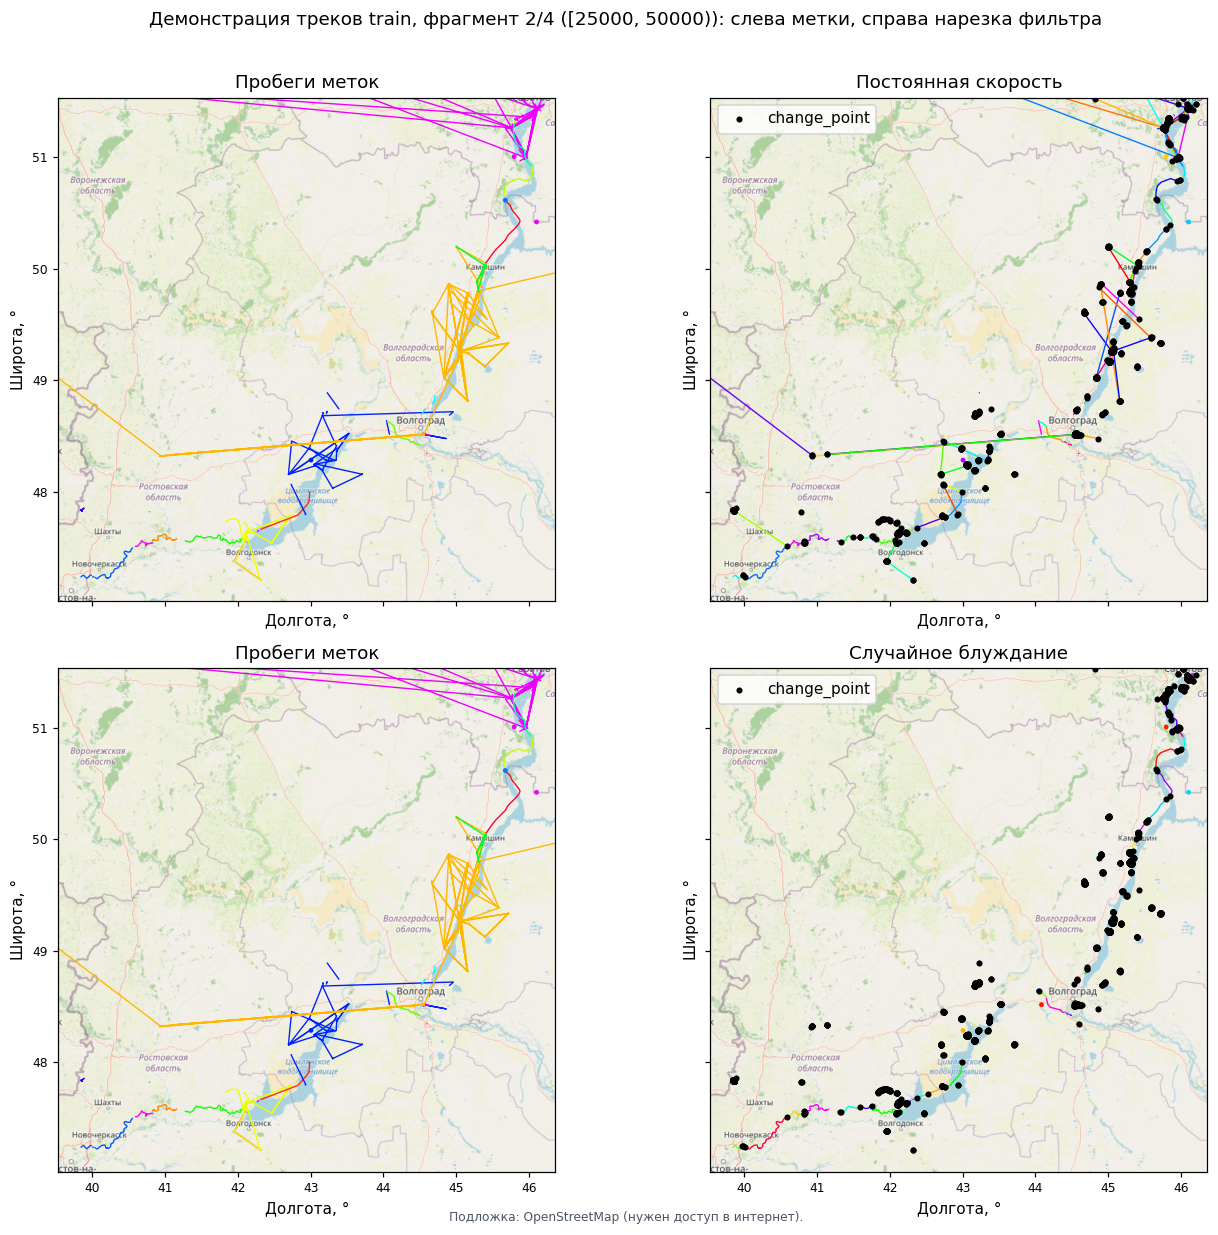

Демонстрация треков train, фрагмент 3/4: глобальные индексы [50000, 75000), точек 25000.


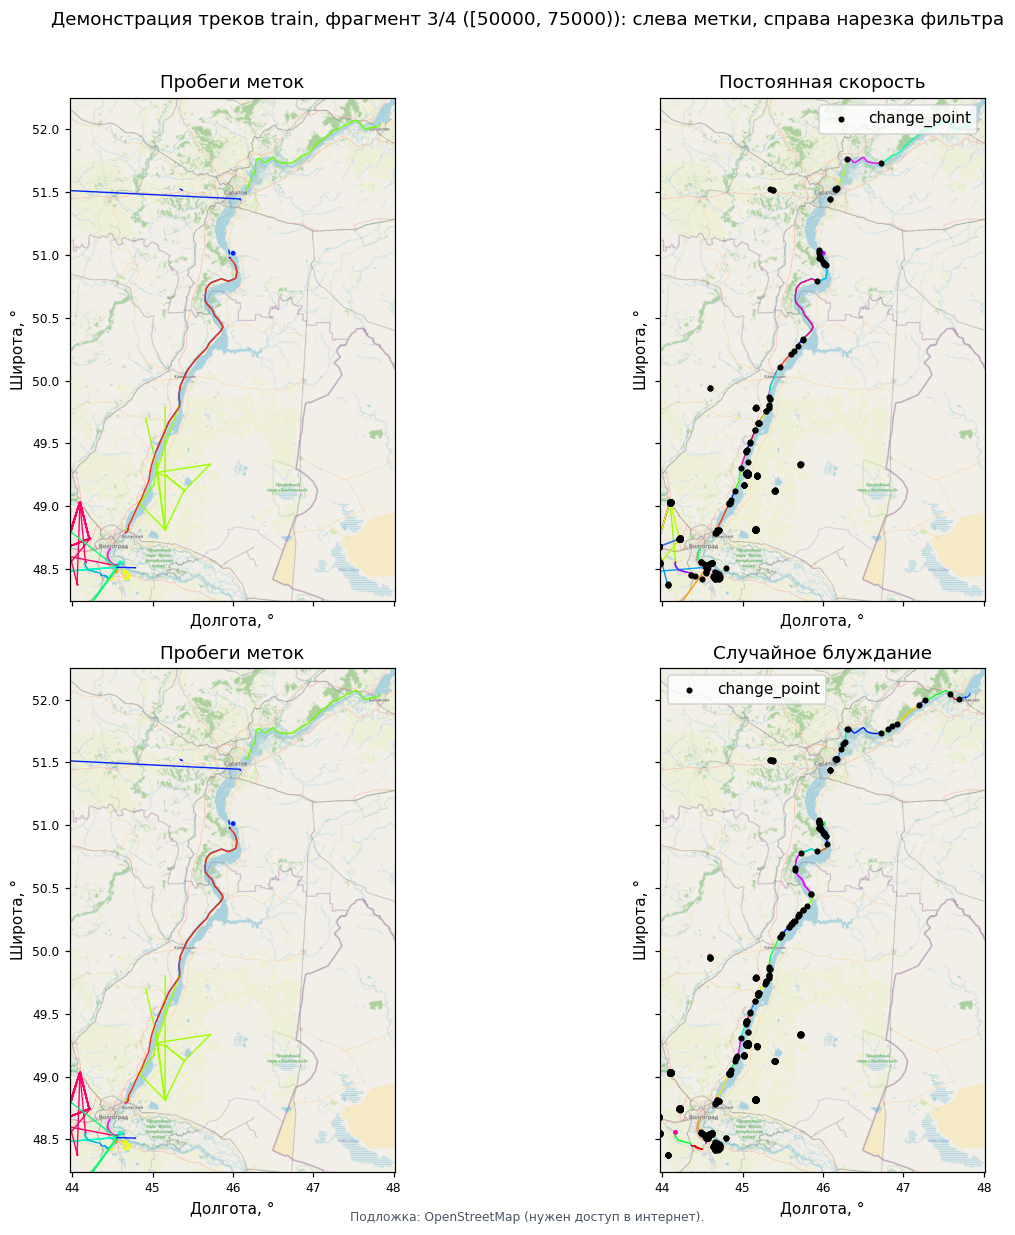

Демонстрация треков train, фрагмент 4/4: глобальные индексы [75000, 93158), точек 18158.


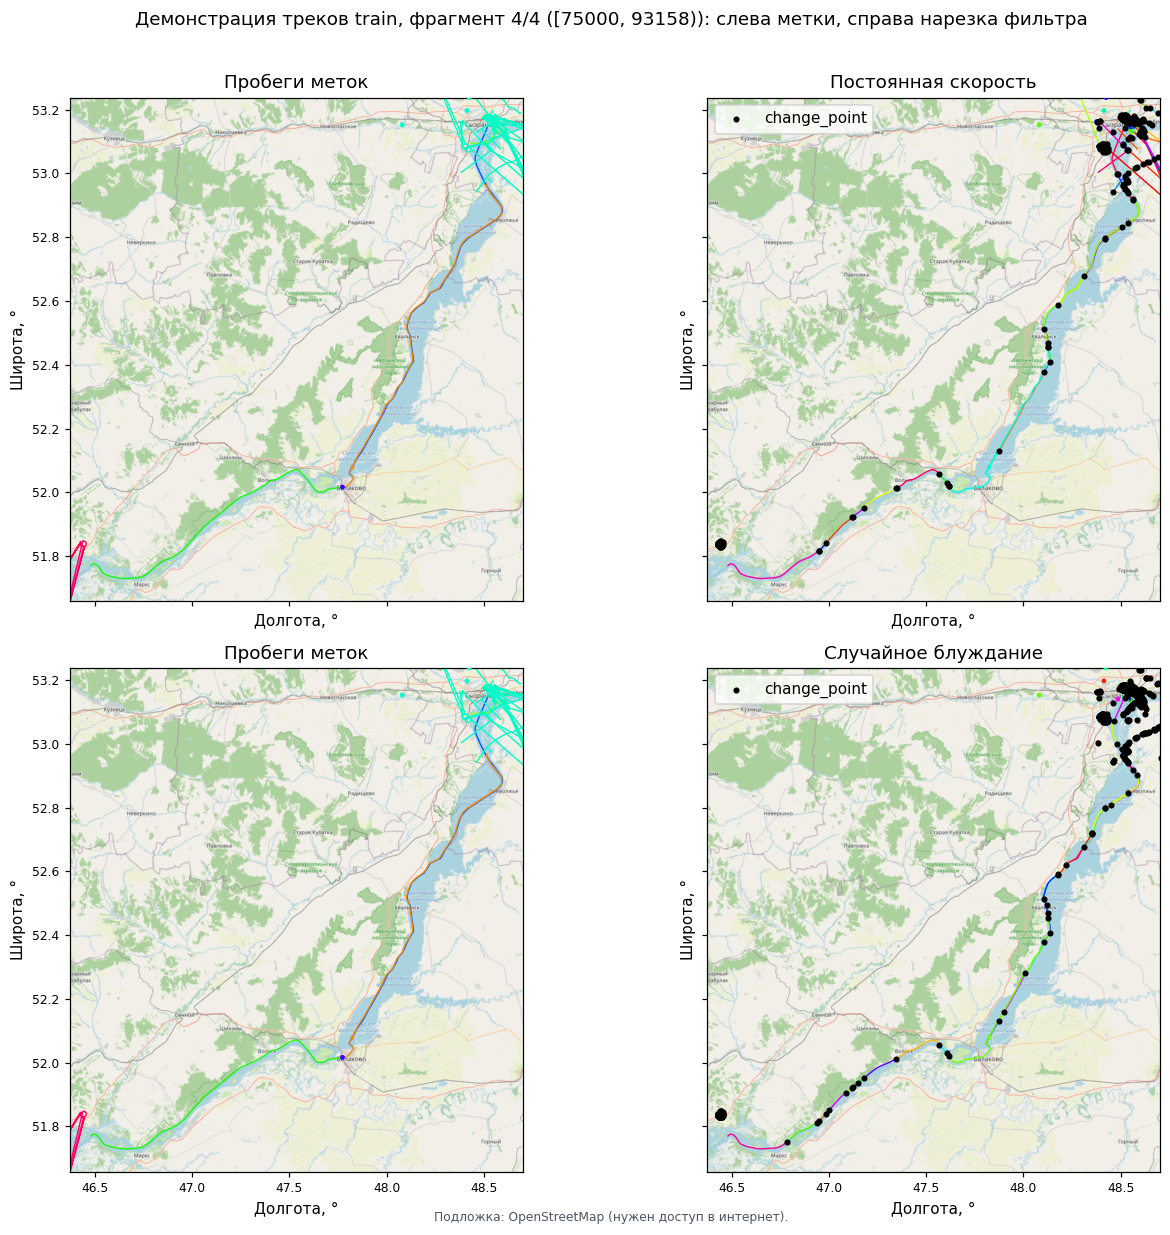


=== Демонстрация треков test ===
Точек в выборке: 50 000, фрагментов по 25 000: 2.
Демонстрация треков test, фрагмент 1/2: глобальные индексы [93158, 118158), точек 25000.


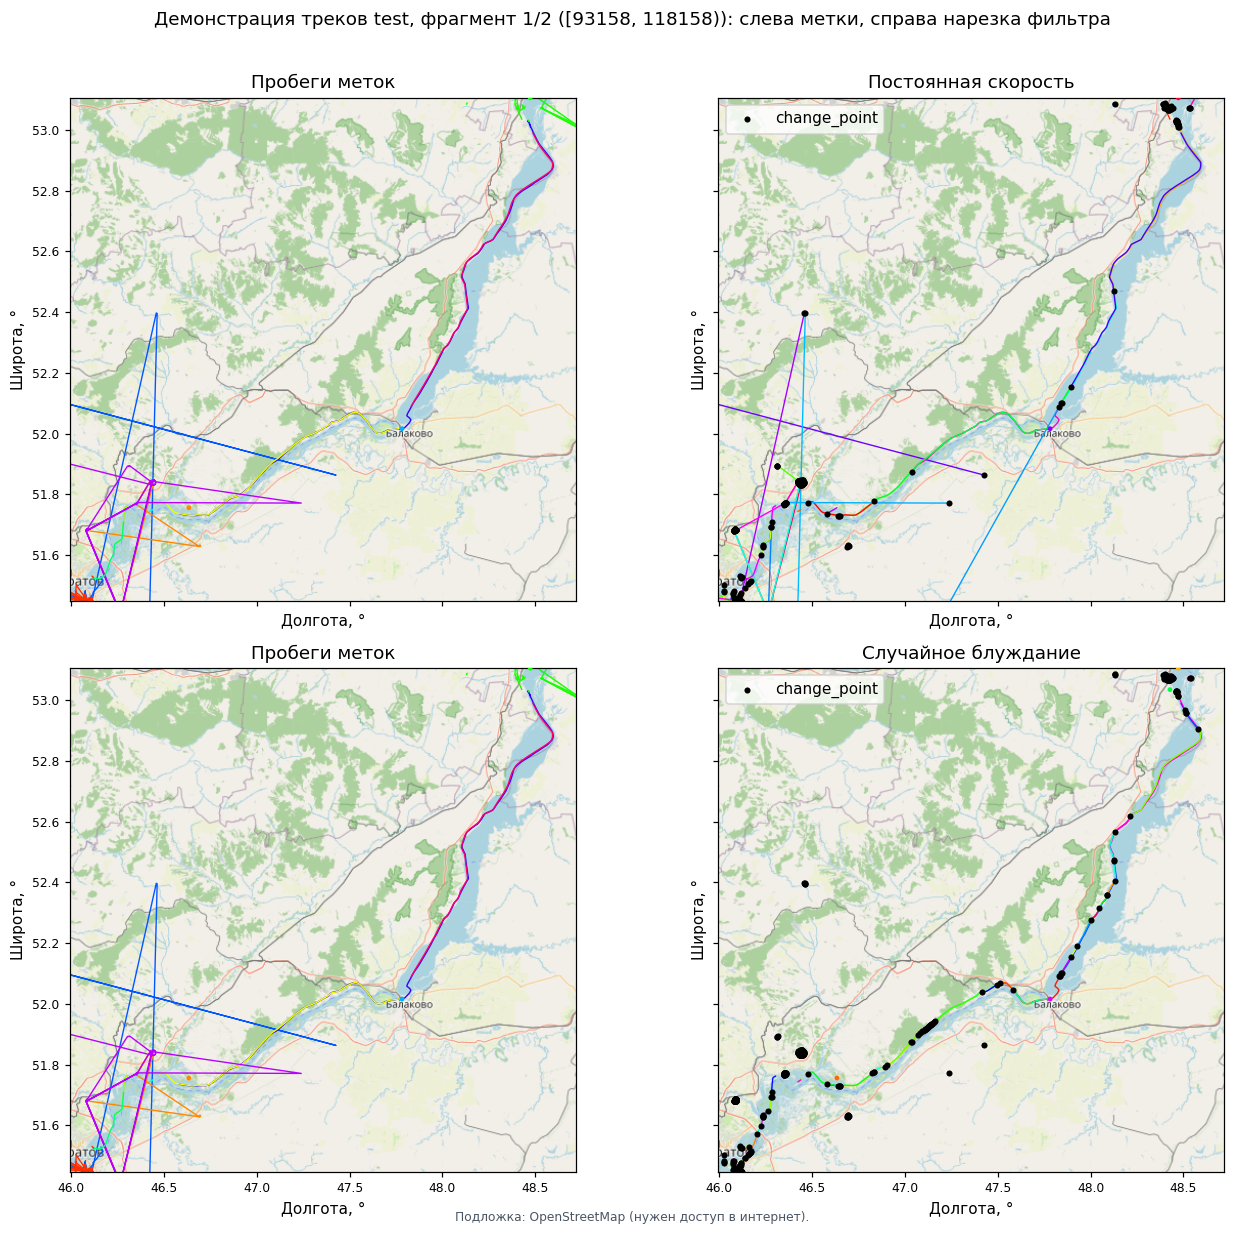

Демонстрация треков test, фрагмент 2/2: глобальные индексы [118158, 143158), точек 25000.


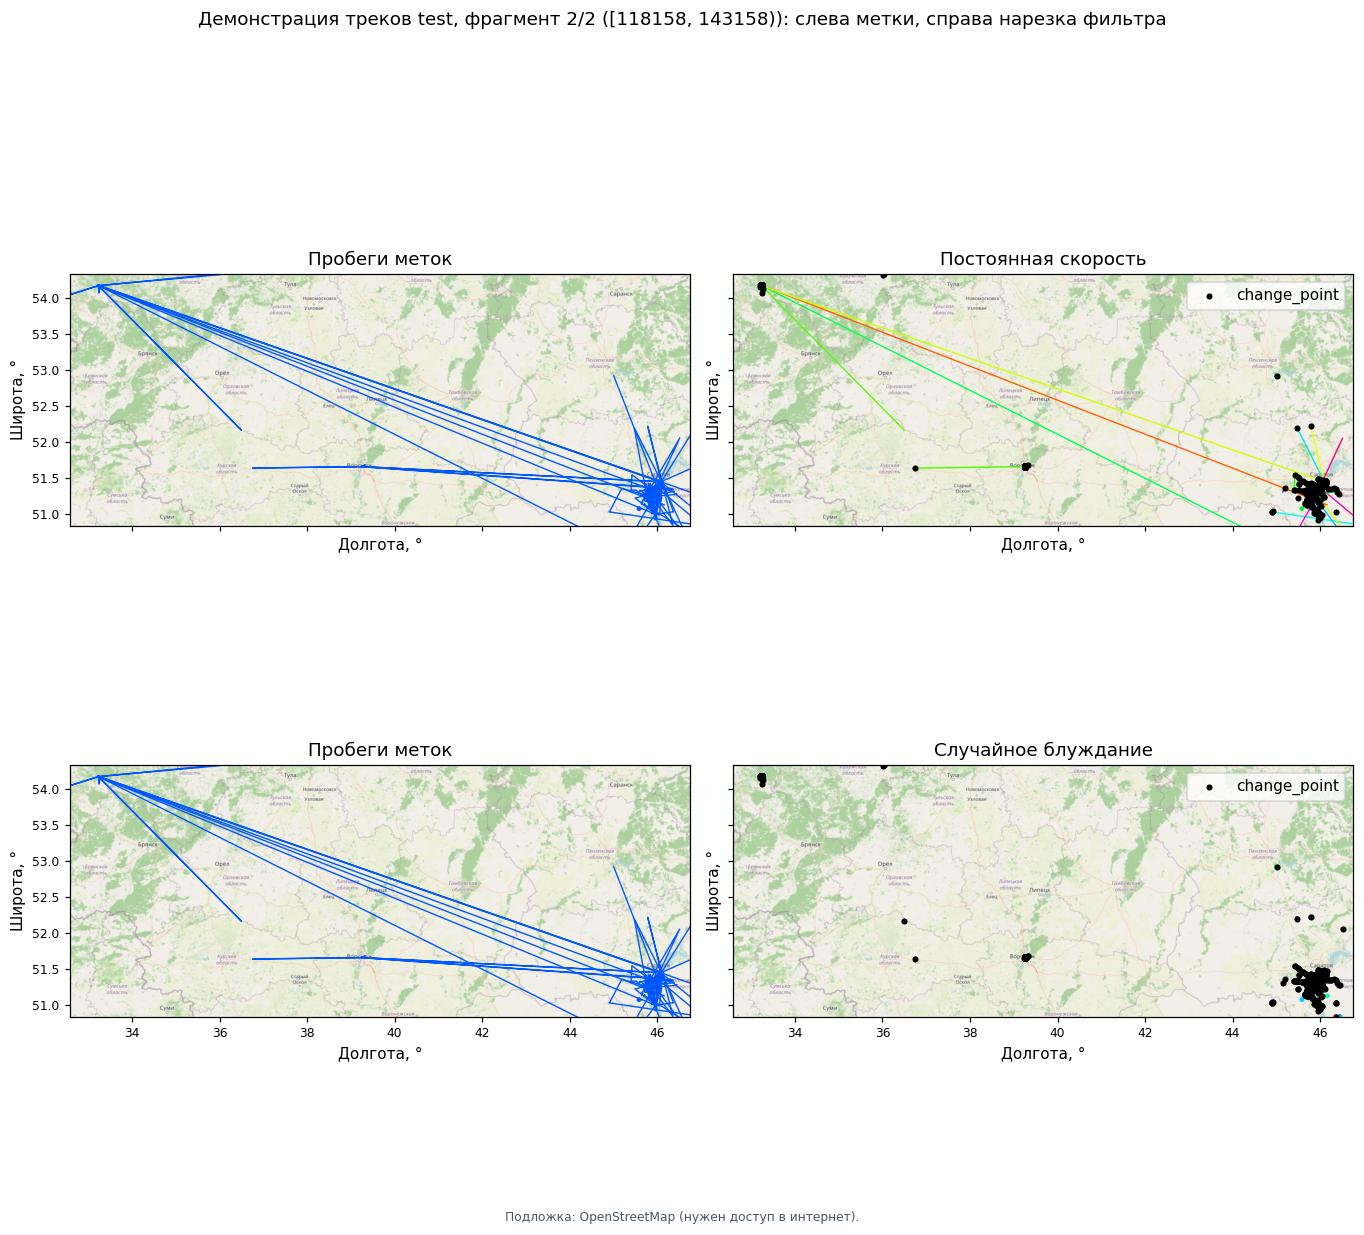

In [25]:
if str(path_root) not in sys.path:
    sys.path.insert(0, str(path_root))

from app.metrics.plot_sample_track import _MAP_CAPTION, _draw_basemap, _load_basemap

TRACK_CHUNK_SIZE = 25_000
_MIN_SPAN_DEG = 0.01
_VIEW_PAD_FRAC = 0.05


def strokes(x_coord, y_coord, group, time, gap=GAP_SECONDS):
    # Куски ломаной: новый кусок на смене группы и на длинной паузе.
    gid = int(group[0])
    chunk = [[float(x_coord[0]), float(y_coord[0])]]
    start = 0
    produced = []
    for index in range(1, len(group)):
        dt = float(time[index] - time[index - 1])
        if int(group[index]) != gid or dt > gap or dt <= 0.0:
            produced.append((gid, start, index, chunk))
            gid = int(group[index])
            chunk = [[float(x_coord[index]), float(y_coord[index])]]
            start = index
        else:
            chunk.append([float(x_coord[index]), float(y_coord[index])])
    produced.append((gid, start, len(group), chunk))
    return produced


def segment_color(sid):
    hue = (0.61803398875 * (int(sid) + 1)) % 1.0
    return plt.cm.hsv(hue)


def _pad_view_limits(south, north, west, east):
    lat_span = max(float(north - south), _MIN_SPAN_DEG)
    lon_span = max(float(east - west), _MIN_SPAN_DEG)
    south -= _VIEW_PAD_FRAC * lat_span
    north += _VIEW_PAD_FRAC * lat_span
    west -= _VIEW_PAD_FRAC * lon_span
    east += _VIEW_PAD_FRAC * lon_span
    return float(west), float(east), float(south), float(north)


def map_view_limits(lat_s, lon_s, is_move):
    """Границы карты: west, east, south, north в градусах."""
    lat_s = np.asarray(lat_s, dtype=float)
    lon_s = np.asarray(lon_s, dtype=float)
    is_move = np.asarray(is_move, dtype=bool)
    if is_move.shape[0] != lat_s.shape[0]:
        raise ValueError("is_move должен совпадать по длине с lat/lon")

    if np.any(is_move):
        lat_use = lat_s[is_move]
        lon_use = lon_s[is_move]
        south, north = float(np.min(lat_use)), float(np.max(lat_use))
        west, east = float(np.min(lon_use)), float(np.max(lon_use))
        return _pad_view_limits(south, north, west, east)

    if lat_s.size >= 4:
        south, north = np.percentile(lat_s, [2.5, 97.5])
        west, east = np.percentile(lon_s, [2.5, 97.5])
    else:
        south, north = float(np.min(lat_s)), float(np.max(lat_s))
        west, east = float(np.min(lon_s)), float(np.max(lon_s))
    return _pad_view_limits(south, north, west, east)


def draw_partition(
    ax,
    lat_s,
    lon_s,
    time,
    group,
    title,
    change=None,
    linewidth=0.8,
    limits=None,
    basemap=None,
):
    if limits is None:
        raise ValueError("limits обязательны для отрисовки на карте")
    _draw_basemap(ax, basemap, limits)

    lines = []
    colors = []
    single_x = []
    single_y = []
    single_c = []
    for gid, start, stop, chunk in strokes(lon_s, lat_s, group, time):
        color = segment_color(gid)
        if len(chunk) >= 2:
            lines.append(chunk)
            colors.append(color)
        else:
            single_x.append(chunk[0][0])
            single_y.append(chunk[0][1])
            single_c.append(color)
    if lines:
        ax.add_collection(
            LineCollection(
                lines,
                colors=colors,
                linewidths=linewidth,
                capstyle="round",
                zorder=2,
            )
        )
    if single_x:
        ax.scatter(single_x, single_y, c=single_c, s=10, linewidths=0, zorder=3)
    if change is not None and np.any(change):
        ax.scatter(
            lon_s[change],
            lat_s[change],
            s=16,
            c="black",
            marker="o",
            linewidths=0,
            zorder=4,
            label="change_point",
        )
    ax.set_title(title)


def geographic_lines(lon_s, lat_s, time, group):
    lines = []
    owners = []
    for gid, start, stop, chunk in strokes(lon_s, lat_s, group, time):
        if len(chunk) < 2:
            continue
        lines.append(LineString(chunk))
        owners.append(gid)
    return lines, owners


def segment_frame(kind, split_slice, seg):
    lon_s = lon[split_slice]
    lat_s = lat[split_slice]
    time = t_sec[split_slice]
    mask = anom[split_slice]
    lines, owners = geographic_lines(lon_s, lat_s, time, seg)
    rows = []
    by_owner = {}
    for line, gid in zip(lines, owners):
        by_owner.setdefault(gid, []).append(line)
    for gid in np.unique(seg):
        chosen = seg == gid
        n_points = int(chosen.sum())
        n_anom = int(np.count_nonzero(mask[chosen]))
        majority = "anomaly" if n_anom * 2 >= n_points else "move"
        purity = max(n_anom, n_points - n_anom) / n_points
        parts = by_owner.get(int(gid), [])
        geometry = parts[0] if len(parts) == 1 else None
        if len(parts) > 1:
            geometry = parts
        rows.append(
            {
                "модель": "постоянная скорость" if kind == "cv" else "случайное блуждание",
                "segment_id": int(gid),
                "n_points": n_points,
                "majority": majority,
                "purity": purity,
                "n_linestrings": len(parts),
                "geometry": geometry,
            }
        )
    return pd.DataFrame(rows)


def _chunk_ranges(n_points, chunk_size=TRACK_CHUNK_SIZE):
    for start in range(0, n_points, chunk_size):
        yield start, min(start + chunk_size, n_points)


def plot_split_track_maps(split_title, split_key, global_lo):
    n_points = train_end if split_key == "train" else len(frame) - train_end
    ranges = list(_chunk_ranges(n_points))
    print(f"\n=== {split_title} ===")
    print(f"Точек в выборке: {nfmt(n_points)}, фрагментов по {nfmt(TRACK_CHUNK_SIZE)}: {len(ranges)}.")

    for part_index, (rel_lo, rel_hi) in enumerate(ranges, start=1):
        point_lo = global_lo + rel_lo
        point_hi = global_lo + rel_hi
        sl = slice(point_lo, point_hi)
        lat_s = lat[sl]
        lon_s = lon[sl]
        time_s = t_sec[sl]
        anom_s = anom[sl]
        limits = map_view_limits(lat_s, lon_s, ~anom_s)
        basemap = _load_basemap(limits[0], limits[2], limits[1], limits[3])
        label_run = class_run_id(anom_s)

        cv_cut = runs[("cv", split_key, "cut")]
        rw_cut = runs[("rw", split_key, "cut")]
        rel_sl = slice(rel_lo, rel_hi)

        print(
            f"{split_title}, фрагмент {part_index}/{len(ranges)}: "
            f"глобальные индексы [{point_lo}, {point_hi}), точек {rel_hi - rel_lo}."
        )

        fig, axes = plt.subplots(2, 2, figsize=(12.5, 11), sharex=True, sharey=True)
        draw_partition(
            axes[0, 0],
            lat_s,
            lon_s,
            time_s,
            label_run,
            "Пробеги меток",
            linewidth=0.9,
            limits=limits,
            basemap=basemap,
        )
        draw_partition(
            axes[0, 1],
            lat_s,
            lon_s,
            time_s,
            cv_cut[5][rel_sl],
            "Постоянная скорость",
            change=cv_cut[3][rel_sl],
            linewidth=0.9,
            limits=limits,
            basemap=basemap,
        )
        draw_partition(
            axes[1, 0],
            lat_s,
            lon_s,
            time_s,
            label_run,
            "Пробеги меток",
            linewidth=0.9,
            limits=limits,
            basemap=basemap,
        )
        draw_partition(
            axes[1, 1],
            lat_s,
            lon_s,
            time_s,
            rw_cut[5][rel_sl],
            "Случайное блуждание",
            change=rw_cut[3][rel_sl],
            linewidth=0.9,
            limits=limits,
            basemap=basemap,
        )
        axes[0, 1].legend(loc="best", frameon=True)
        axes[1, 1].legend(loc="best", frameon=True)
        fig.suptitle(
            f"{split_title}, фрагмент {part_index}/{len(ranges)} "
            f"([{point_lo}, {point_hi})): слева метки, справа нарезка фильтра",
            y=1.01,
        )
        fig.text(0.5, 0.01, _MAP_CAPTION, ha="center", fontsize=8, color="#4b5563")
        fig.tight_layout()
        plt.show()


test_slice = slice(train_end, len(frame))
test_anom = anom[test_slice]
test_run = class_run_id(test_anom)
test_time = t_sec[test_slice]
test_lat = lat[test_slice]
test_lon = lon[test_slice]

longest = max(
    (
        (int(np.count_nonzero(test_run == sid)), int(np.flatnonzero(test_run == sid)[0]))
        for sid in np.unique(test_run)
        if not test_anom[test_run == sid][0]
    ),
    key=lambda item: item[0],
)
zoom_lo = max(0, longest[1] - 700)
zoom_hi = min(len(test_anom), int(np.flatnonzero(test_run == test_run[longest[1]])[-1]) + 701)
zoom = slice(zoom_lo, zoom_hi)

segment_tables = {}
line_counts = {}
for kind in ("cv", "rw"):
    seg = runs[(kind, "test", "cut")][5]
    segment_tables[kind] = segment_frame(kind, test_slice, seg)
    n_lines = int(segment_tables[kind]["n_linestrings"].sum())
    n_single = int((segment_tables[kind]["n_points"] == 1).sum())
    line_counts[kind] = (n_lines, n_single)
    title = "Постоянная скорость" if kind == "cv" else "Случайное блуждание"
    print(
        f"{title}: {len(segment_tables[kind])} систем координат, "
        f"{n_lines} LineString, одиночных точек без ребра {n_single}."
    )

preview = pd.concat(
    [
        segment_tables["cv"].drop(columns="geometry").head(6),
        segment_tables["rw"].drop(columns="geometry").head(6),
    ],
    ignore_index=True,
)
display(preview.round(3))

plot_split_track_maps("Демонстрация треков train", "train", 0)
plot_split_track_maps("Демонстрация треков test", "test", train_end)


# Правдоподобие на тесте

Слева — функция распределения сырого фильтра: система меняется только на паузе, поэтому виден провал на точках, которые фильтр ещё не выкинул из текущего режима. Справа — тот же порог на окне длинного `move`, уже с `change_point`. Обе оси `log p` симметрично-логарифмические: полоса хода и глубокие провалы стоят на одном графике. Розовая полоса справа — точки `anomaly`.

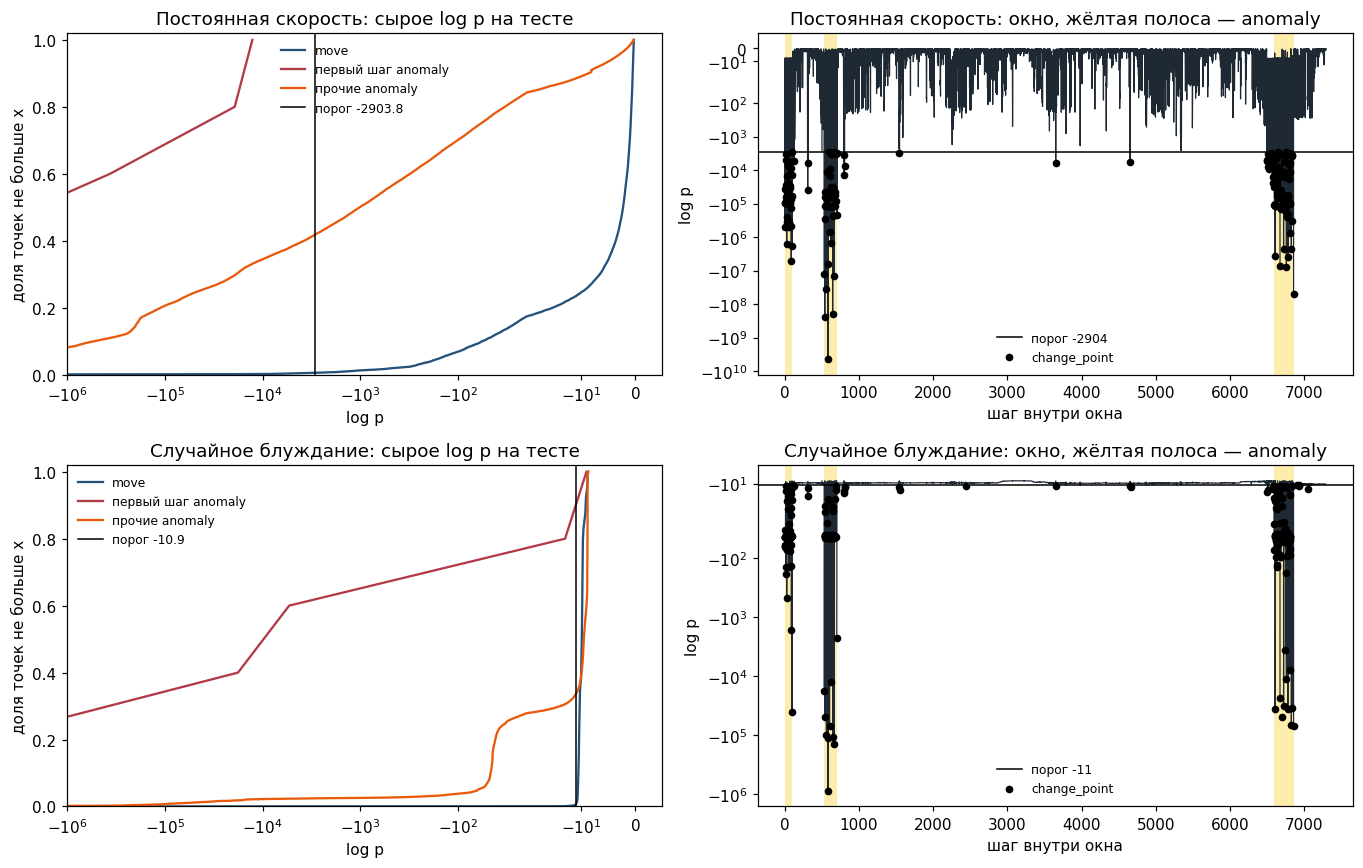

In [26]:
def plot_loglik_hist(ax, groups, tau, title):
    # Функция распределения, ось log p симметрично-логарифмическая:
    # скачок хода около нуля и масса anomaly далеко слева читаются вместе.
    def draw(values, label, color):
        if len(values) == 0:
            return
        ordered = np.sort(np.asarray(values, dtype=float))
        share = np.arange(1, len(ordered) + 1) / len(ordered)
        ax.plot(ordered, share, label=label, color=color, linewidth=1.5)

    draw(groups["move"], "move", "#24527a")
    draw(groups["to_anomaly"], "первый шаг anomaly", "#b23a48")
    draw(groups["anomaly"], "прочие anomaly", "#e8590c")
    ax.axvline(tau, color="black", linewidth=1.0, label=f"порог {tau:.1f}")
    ax.set_xscale("symlog", linthresh=20)
    ax.set_xlim(-1.0e6, 5)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("log p")
    ax.set_ylabel("доля точек не больше x")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)


def plot_loglik_window(ax, loglik, change, mask, tau, title):
    index = np.arange(len(loglik))
    ax.plot(index, loglik, color="#1f2933", linewidth=0.8)
    ax.axhline(tau, color="black", linewidth=1.0, label=f"порог {tau:.0f}")
    if np.any(change):
        ax.scatter(index[change], loglik[change], s=16, c="black", zorder=3, label="change_point")
    spans = strokes(index.astype(float), np.zeros(len(mask)), mask.astype(int), np.arange(len(mask), dtype=float), gap=10**9)
    for gid, start, stop, _chunk in spans:
        if gid == 1:
            ax.axvspan(start, stop, color="#facc15", alpha=0.35, linewidth=0)
    ax.set_yscale("symlog", linthresh=30)
    ax.set_title(title)
    ax.set_xlabel("шаг внутри окна")
    ax.set_ylabel("log p")
    ax.legend(frameon=False, fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(12.5, 8))
for row, kind, title, tau in (
    (0, "cv", "Постоянная скорость", tau_cv),
    (1, "rw", "Случайное блуждание", tau_rw),
):
    groups = scout_groups(test_anom, runs[(kind, "test", "scout")][0])
    plot_loglik_hist(axes[row, 0], groups, tau, f"{title}: сырое log p на тесте")
    window_ll = runs[(kind, "test", "cut")][0][zoom]
    window_change = runs[(kind, "test", "cut")][3][zoom]
    plot_loglik_window(
        axes[row, 1],
        window_ll,
        window_change,
        test_anom[zoom],
        tau,
        f"{title}: окно, жёлтая полоса — anomaly",
    )
fig.tight_layout()
plt.show()

# Выводы

Гипотеза: отрезки между `change_point` фильтра Калмана, подогнанного по `move` обучения, близки к непрерывным пробегам меток `move` и `anomaly` и в первую очередь не смешивают классы. Порог — квантиль 0,5% логарифма правдоподобия на `move` обучения. Проверка на срезе `data/2.csv` `[200000:350000)` после очистки: 143 158 точек, обучение 93 158 (доля `anomaly` 45,1%), тест 50 000 (доля `anomaly` 77,2%). На тесте границ классов всего 12: классы идут длинными кусками, а не чередуются на каждом шаге.

**Классы внутри одного отрезка не смешиваются.** На тесте чистота и однородность равны 1,000 у обеих моделей (на обучении 0,994 и 0,991). Точка `change_point` или пауза длиннее 180 с почти всегда стоит на смене метки или не даёт отрезку захватить оба класса. Все 12 границ на тесте пойманы: 9 — падением правдоподобия, 3 — только паузой. Пропусков границ нет.

**Нарезка не совпадает с пробегами меток.** V-мера на тесте около 0,28, ARI около 0,015 (CV) и 0,011 (RW). Однородность высокая при низкой V означает, что отрезок фильтра чистый, но один пробег метки режется на много отрезков. На тесте постоянная скорость даёт 8 371 отрезок и 8 087 `change_point`, из них 8 050 лежат в `anomaly` и только 37 в `move`. У случайного блуждания ещё мельче: 13 236 отрезков, 12 877 `change_point` внутри `anomaly`. Медиана длины отрезка `anomaly` — 2 точки (CV) и 1 точка (RW); p95 — 12 и 9 точек. Медиана отрезка `move` на тесте — 7 точек (CV, максимум 2 106) и 15 точек (RW, максимум 1 846), при p95 1 880 и 804: длинный ход сохраняется крупными кусками, а короткая медиана — это обрезки на сбоях и паузах.

**Сырое правдоподобие (фильтр без смены системы на каждом провале) отделяет вход в `anomaly`, но не весь класс.** У постоянной скорости медиана log p на тесте: `move` −2,20, первый шаг `move → anomaly` −362 956 (все 5 таких шагов ниже порога −2 904), прочие точки `anomaly` −1 014 и ниже порога лишь в 41,8% случаев. Порог на ходе срабатывает редко (0,52% шагов `move`), как и задумано квантилем 0,5%. У случайного блуждания первый шаг `anomaly` тоже проваливается (медиана −5 348, 4 из 5 шагов ниже порога −10,88), но прочие `anomaly` по медиане (−9,44) почти не отличаются от `move` (−9,82): модель «остаться на месте» с большим шумом процесса быстро принимает новую точку и перестаёт видеть аномалию. Невязка на `move` обучения это подтверждает: медиана 0,90 м у постоянной скорости против 44,5 м у случайного блуждания.

**Итог.** Разделимость `move` и `anomaly` в слабом смысле подтверждается: отрезок фильтра не смешивает классы, а первый шаг ухода с хода роняет правдоподобие ниже порога, особенно у постоянной скорости. В сильном смысле — что `change_point` восстанавливает пробеги меток — гипотеза не подтверждается. Почти все `change_point` лежат внутри `anomaly`, а не на границе классов, поэтому точность `change_point` как детектора границы низкая при полной полноте по редким границам. Для этой задачи постоянная скорость предпочтительнее случайного блуждания: она лучше описывает `move` и сильнее отделяет начало `anomaly`, но обе модели перенарезают `anomaly` на короткие отрезки.
